In [1]:
import pandas as pd
import matplotlib as plt
from pipeline import run_pipeline
import random


# Load & clean data 
posts, quotes, stock = run_pipeline()



<ArrowStringArray>
['2023-07-12 18:00:55+00:00', '2023-07-12 17:58:42+00:00',
 '2023-07-12 17:44:11+00:00', '2023-07-12 17:39:20+00:00',
 '2023-07-12 17:32:49+00:00', '2023-07-12 17:05:03+00:00',
 '2023-07-12 16:23:47+00:00', '2023-07-12 04:47:31+00:00']
Length: 8, dtype: str
['2023-07-13T00:42:58.000000' '2023-07-13T00:41:50.000000'
 '2023-07-12T18:00:55.000000' '2023-07-12T17:58:42.000000'
 '2023-07-12T17:44:11.000000' '2023-07-12T17:39:20.000000'
 '2023-07-12T17:32:49.000000' '2023-07-12T17:05:03.000000'
 '2023-07-12T16:23:47.000000' '2023-07-12T04:47:31.000000']


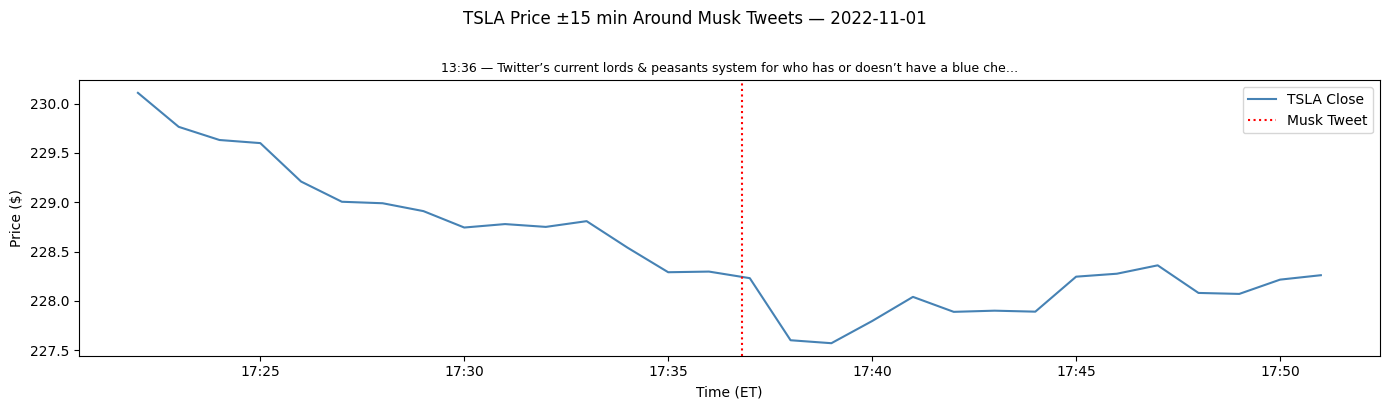


Plotting day: 2022-11-01
Tweets on this day (1):
  13:36 — Twitter’s current lords & peasants system for who has or doesn’t have a blue checkmark is bullshit. Power to the people! Blue for $8/month.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Global
SELECTED_DAY = None  # Set to a date string like "2022-04-04" to pin a day, None for a random day

# Valid days
valid_days = sorted(stock["timestamp"].dt.strftime("%Y-%m-%d").unique())

# Select day
if SELECTED_DAY is None:
    selected_day = random.choice(valid_days)
elif SELECTED_DAY in valid_days:
    selected_day = SELECTED_DAY
else:
    raise ValueError(f"{SELECTED_DAY} is not a valid trading day in the dataset. "
                     f"Valid days range from {valid_days[0]} to {valid_days[-1]}.")

# Filter to selected day
day_stock  = stock[stock["timestamp"].dt.strftime("%Y-%m-%d") == selected_day]
day_tweets = posts[posts["createdAt"].dt.strftime("%Y-%m-%d") == selected_day]

WINDOW = timedelta(minutes=15)

n_tweets = len(day_tweets)
fig, axes = plt.subplots(n_tweets, 1, figsize=(14, 4 * n_tweets), squeeze=False)

for i, (_, tweet) in enumerate(day_tweets.iterrows()):
    ax = axes[i][0]
    tweet_time = tweet["createdAt"]
    window_start = tweet_time - WINDOW
    window_end   = tweet_time + WINDOW

    # Filter stock data to ±15 min window
    window_stock = day_stock[
        (day_stock["timestamp"] >= window_start) &
        (day_stock["timestamp"] <= window_end)
    ]

    ax.plot(window_stock["timestamp"], window_stock["close"],
            label="TSLA Close", color="steelblue", linewidth=1.5)
    ax.axvline(x=tweet_time, color="red", linestyle="dotted",
               linewidth=1.5, label="Musk Tweet")

    # Annotate with tweet text (truncated)
    snippet = tweet["cleanText"][:80] + ("…" if len(tweet["cleanText"]) > 80 else "")
    ax.set_title(f"{tweet_time.strftime('%H:%M')} — {snippet}", fontsize=9)
    ax.set_xlabel("Time (ET)")
    ax.set_ylabel("Price ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend()

fig.suptitle(f"TSLA Price ±15 min Around Musk Tweets — {selected_day}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPlotting day: {selected_day}")
print(f"Tweets on this day ({n_tweets}):")
for _, tweet in day_tweets.iterrows():
    print(f"  {tweet['createdAt'].strftime('%H:%M')} — {tweet['cleanText']}")

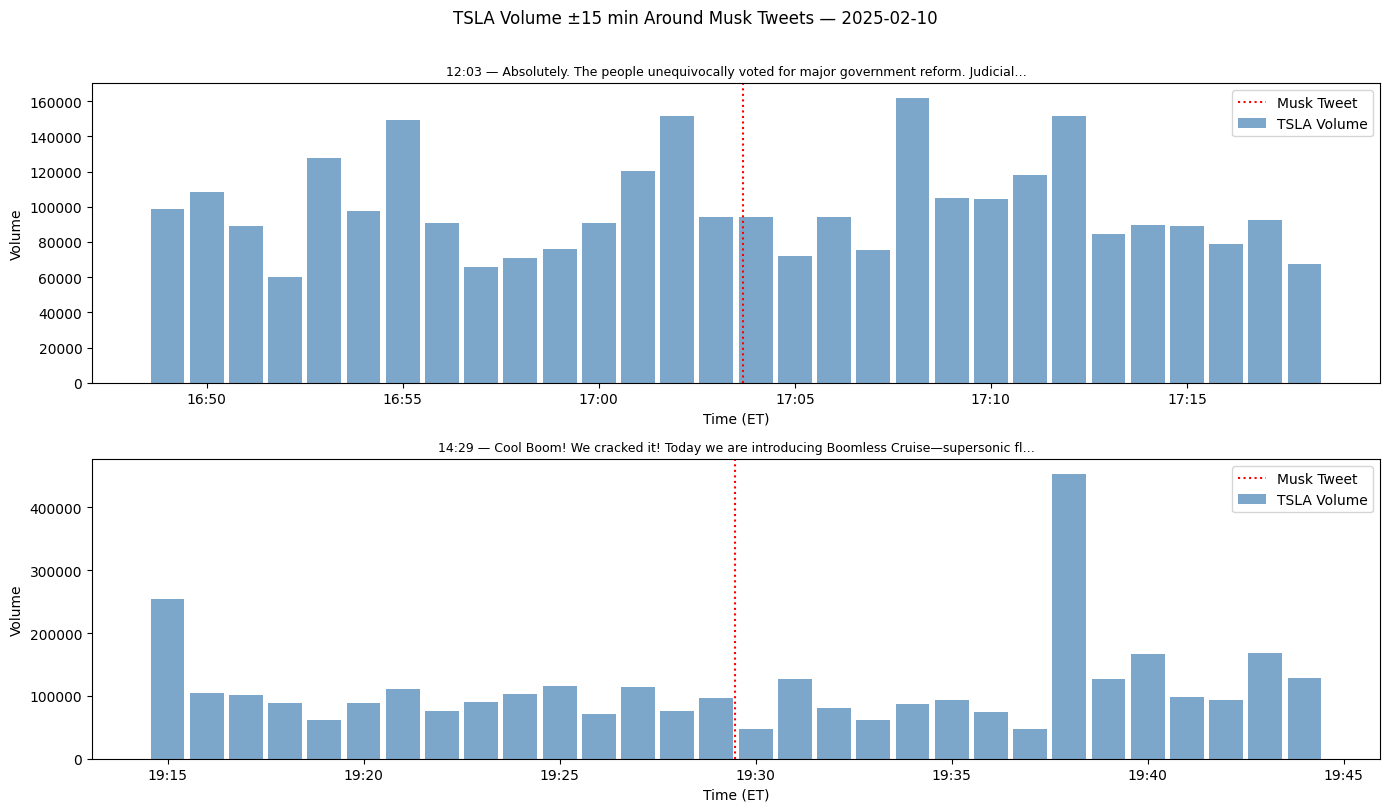


Plotting day: 2025-02-10
Tweets on this day (2):
  12:03 — Absolutely. The people unequivocally voted for major government reform. Judicial tyranny is grossly improper! 🚨🇺🇸 TRUMP FIGHTS “UNCONSTITUTIONAL” TREASURY BLOCKADE After a judge barred top Treasury officials from accessing the federal payment system, Trump’s team hit back, demanding an immediate reversal. The order came after states sued over DOGE employees having access, claiming security risks - but Trump’s DOJ says this is just an excuse to sideline his administration. The White House warned that blocking Treasury leaders from their own system is a dangerous overreach. Source: Politico
  14:29 — Cool Boom! We cracked it! Today we are introducing Boomless Cruise—supersonic flights up to 50% faster with no audible sonic boom. We quietly (har har) demo'd this on XB-1's first supersonic flight—three times actually. 🧵👇


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Global
SELECTED_DAY = None  # Set to a date string like "2022-04-04" to pin a day

# Valid days
valid_days = sorted(stock["timestamp"].dt.strftime("%Y-%m-%d").unique())

# Select day
if SELECTED_DAY is None:
    selected_day = random.choice(valid_days)
elif SELECTED_DAY in valid_days:
    selected_day = SELECTED_DAY
else:
    raise ValueError(f"{SELECTED_DAY} is not a valid trading day in the dataset. "
                     f"Valid days range from {valid_days[0]} to {valid_days[-1]}.")

# Filter to selected day, excluding first and last 15 minutes
day_stock  = stock[stock["timestamp"].dt.strftime("%Y-%m-%d") == selected_day]
day_tweets = posts[posts["createdAt"].dt.strftime("%Y-%m-%d") == selected_day]

day_stock = day_stock[
    (day_stock["timestamp"].dt.time >= pd.Timestamp("09:45").time()) &
    (day_stock["timestamp"].dt.time <= pd.Timestamp("15:45").time())
]

WINDOW = timedelta(minutes=15)

n_tweets = len(day_tweets)
fig, axes = plt.subplots(n_tweets, 1, figsize=(14, 4 * n_tweets), squeeze=False)

for i, (_, tweet) in enumerate(day_tweets.iterrows()):
    ax = axes[i][0]
    tweet_time = tweet["createdAt"]
    window_start = tweet_time - WINDOW
    window_end   = tweet_time + WINDOW

    # Filter stock data to ±15 min window
    window_stock = day_stock[
        (day_stock["timestamp"] >= window_start) &
        (day_stock["timestamp"] <= window_end)
    ]

    ax.bar(window_stock["timestamp"], window_stock["volume"],
           width=0.0006, label="TSLA Volume", color="steelblue", alpha=0.7)
    ax.axvline(x=tweet_time, color="red", linestyle="dotted",
               linewidth=1.5, label="Musk Tweet")

    # Annotate with tweet text (truncated)
    snippet = tweet["cleanText"][:80] + ("…" if len(tweet["cleanText"]) > 80 else "")
    ax.set_title(f"{tweet_time.strftime('%H:%M')} — {snippet}", fontsize=9)
    ax.set_xlabel("Time (ET)")
    ax.set_ylabel("Volume")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend()

fig.suptitle(f"TSLA Volume ±15 min Around Musk Tweets — {selected_day}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPlotting day: {selected_day}")
print(f"Tweets on this day ({n_tweets}):")
for _, tweet in day_tweets.iterrows():
    print(f"  {tweet['createdAt'].strftime('%H:%M')} — {tweet['cleanText']}")

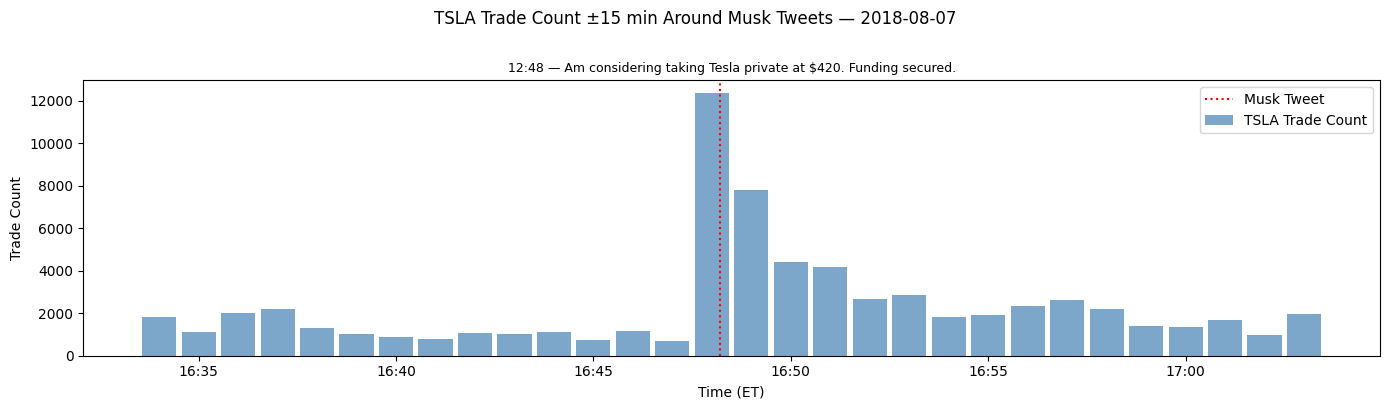


Plotting day: 2018-08-07
Tweets on this day (1):
  12:48 — Am considering taking Tesla private at $420. Funding secured.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

# Global
SELECTED_DAY = '2018-08-07'  # Set to a date string like "2022-04-04" to pin a day

# Valid days
valid_days = sorted(stock["timestamp"].dt.strftime("%Y-%m-%d").unique())

# Select day
if SELECTED_DAY is None:
    selected_day = random.choice(valid_days)
elif SELECTED_DAY in valid_days:
    selected_day = SELECTED_DAY
else:
    raise ValueError(f"{SELECTED_DAY} is not a valid trading day in the dataset. "
                     f"Valid days range from {valid_days[0]} to {valid_days[-1]}.")

# Filter to selected day, excluding first and last 15 minutes
day_stock  = stock[stock["timestamp"].dt.strftime("%Y-%m-%d") == selected_day]
day_tweets = posts[posts["createdAt"].dt.strftime("%Y-%m-%d") == selected_day]

day_stock = day_stock[
    (day_stock["timestamp"].dt.time >= pd.Timestamp("09:45").time()) &
    (day_stock["timestamp"].dt.time <= pd.Timestamp("15:45").time())
]

WINDOW = timedelta(minutes=15)

n_tweets = len(day_tweets)
fig, axes = plt.subplots(n_tweets, 1, figsize=(14, 4 * n_tweets), squeeze=False)

for i, (_, tweet) in enumerate(day_tweets.iterrows()):
    ax = axes[i][0]
    tweet_time = tweet["createdAt"]
    window_start = tweet_time - WINDOW
    window_end   = tweet_time + WINDOW

    # Filter stock data to ±15 min window
    window_stock = day_stock[
        (day_stock["timestamp"] >= window_start) &
        (day_stock["timestamp"] <= window_end)
    ]

    ax.bar(window_stock["timestamp"], window_stock["trade_count"],
           width=0.0006, label="TSLA Trade Count", color="steelblue", alpha=0.7)
    ax.axvline(x=tweet_time, color="red", linestyle="dotted",
               linewidth=1.5, label="Musk Tweet")

    snippet = tweet["cleanText"][:80] + ("…" if len(tweet["cleanText"]) > 80 else "")
    ax.set_title(f"{tweet_time.strftime('%H:%M')} — {snippet}", fontsize=9)
    ax.set_xlabel("Time (ET)")
    ax.set_ylabel("Trade Count")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend()

fig.suptitle(f"TSLA Trade Count ±15 min Around Musk Tweets — {selected_day}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPlotting day: {selected_day}")
print(f"Tweets on this day ({n_tweets}):")
for _, tweet in day_tweets.iterrows():
    print(f"  {tweet['createdAt'].strftime('%H:%M')} — {tweet['cleanText']}")